# Get Grid of California Addresses and their transportation info to campus, as well as gas prices and electric vehicle charging rates, using Python and relevant APIs

---

## Import Libraries, Set Up API Keys

In [18]:
import numpy as np 
import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv
import googlemaps

load_dotenv('.env')

gmaps = googlemaps.Client(key=os.getenv('API_KEY'))

## Within range of lat/lng pairs, reverse geocode lat/lng pairs to valid addresses, put into a Dataframe, then gather getDirections data from each valid address and put into column in Dataframe across multiple transportation modes

In [19]:
grid_df = pd.DataFrame(columns = ['latitude', 'longitude', 'address', 'driving_time_to_campus', 'walking_time_to_campus', 'bicycling_time_to_campus', 'transit_time_to_campus'])
latitudes = np.arange(40.0, 41.3, 0.01)  # Northern latitude range for CA county
longitudes = np.arange(-124.5, -123.0, 0.01)  # Western longitude range for CA county

In [20]:
for lat in latitudes:
    for lng in longitudes:
        # Reverse geocode to get address
        reverse_geocode_result = gmaps.reverse_geocode((lat, lng))
        if reverse_geocode_result:
            address = reverse_geocode_result[0]['formatted_address']
            
            # Get directions to campus for different modes of transportation
            # Address: 1 Harpst St. Arcata CA 95521
            driving_directions = gmaps.directions(address, "California State Polytechnic University, Humboldt", mode="driving")
            walking_directions = gmaps.directions(address, "California State Polytechnic University, Humboldt", mode="walking")
            bicycling_directions = gmaps.directions(address, "California State Polytechnic University, Humboldt", mode="bicycling")
            transit_directions = gmaps.directions(address, "California State Polytechnic University, Humboldt", mode="transit")
            if driving_directions and walking_directions and bicycling_directions and transit_directions:
                driving_time = driving_directions[0]['legs'][0]['duration']['text']
                walking_time = walking_directions[0]['legs'][0]['duration']['text']
                bicycling_time = bicycling_directions[0]['legs'][0]['duration']['text']
                transit_time = transit_directions[0]['legs'][0]['duration']['text']
                
                # Append to DataFrame
                grid_df = pd.concat([grid_df, pd.DataFrame({
                    'latitude': [lat],
                    'longitude': [lng],
                    'address': [address],
                    'driving_time_to_campus': [driving_time],
                    'walking_time_to_campus': [walking_time],
                    'bicycling_time_to_campus': [bicycling_time],
                    'transit_time_to_campus': [transit_time]
                })], ignore_index=True)

C:\Users\wolfe\AppData\Local\Temp\ipykernel_31464\1577985607.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grid_df = pd.concat([grid_df, pd.DataFrame({


In [21]:
grid_df.shape

(775, 7)

In [23]:
grid_df.head()

,latitude,longitude,address,driving_time_to_campus,walking_time_to_campus,bicycling_time_to_campus,transit_time_to_campus
0,40.06,-123.80,"356X+2X Benbow, CA, USA",1 hour 27 mins,1 day 13 hours,11 hours 18 mins,3 hours 26 mins
1,40.06,-123.79,"3666+22 Benbow, CA, USA",1 hour 31 mins,1 day 13 hours,11 hours 19 mins,3 hours 24 mins
2,40.06,-123.78,"3669+2X Benbow, CA, USA",1 hour 22 mins,1 day 13 hours,11 hours 15 mins,3 hours 10 mins
3,40.06,-123.77,"366J+22 Benbow, CA, USA",1 hour 27 mins,1 day 13 hours,11 hours 20 mins,3 hours 30 mins
4,40.07,-123.81,"359R+X2 Garberville, CA, USA",1 hour 27 mins,1 day 13 hours,11 hours 20 mins,9 hours 41 mins


In [22]:
grid_df.to_csv('../clean_data/Grid_Data_01.csv', index=False)

## Convert Text of Transportation times into minutes in Dataframe, then save Dataframe as CSV again

In [29]:
grid_df = pd.read_csv('../clean_data/Grid_Data_01.csv')

In [ ]:
def text_to_hours(time_str):
    if 'day' in time_str:
        parts = time_str.split()
        days = int(parts[0])
        if 'hour' in time_str:
            hours = int(parts[2])
            if 'min' in time_str:
                minutes = int(parts[4])
                return days * 24 + hours + minutes / 60.0
            return days * 24 + hours
        return days * 24
    elif 'hour' in time_str:
        parts = time_str.split()
        hours = int(parts[0])
        if 'min' in time_str:
            minutes = int(parts[2])
            return hours + minutes / 60.0
        return hours
    else:
        parts = time_str.split()
        minutes = int(parts[0])
        return minutes / 60.0
    
grid_df['driving_time_to_campus'] = grid_df['driving_time_to_campus'].apply(text_to_hours)
grid_df['walking_time_to_campus'] = grid_df['walking_time_to_campus'].apply(text_to_hours)
grid_df['bicycling_time_to_campus'] = grid_df['bicycling_time_to_campus'].apply(text_to_hours)
grid_df['transit_time_to_campus'] = grid_df['transit_time_to_campus'].apply(text_to_hours)

In [31]:
# convert hours to minutes and round to nearest integer

grid_df['driving_time_to_campus'] = (grid_df['driving_time_to_campus'] * 60).round().astype(int)
grid_df['walking_time_to_campus'] = (grid_df['walking_time_to_campus'] * 60).round().astype(int)
grid_df['bicycling_time_to_campus'] = (grid_df['bicycling_time_to_campus'] * 60).round().astype(int)
grid_df['transit_time_to_campus'] = (grid_df['transit_time_to_campus'] * 60).round().astype(int)

grid_df.head()

,latitude,longitude,address,driving_time_to_campus,walking_time_to_campus,bicycling_time_to_campus,transit_time_to_campus
0,40.06,-123.80,"356X+2X Benbow, CA, USA",87,2220,678,206
1,40.06,-123.79,"3666+22 Benbow, CA, USA",91,2220,679,204
2,40.06,-123.78,"3669+2X Benbow, CA, USA",82,2220,675,190
3,40.06,-123.77,"366J+22 Benbow, CA, USA",87,2220,680,210
4,40.07,-123.81,"359R+X2 Garberville, CA, USA",87,2220,680,581


In [33]:
grid_df.to_csv('../clean_data/Humboldt_Travel_Times_Grid.csv', index=False)

## Plot Histograms of Transportation times across different modes of transportation to identify any modality that allows us to cluster addresses by transportation time to campus

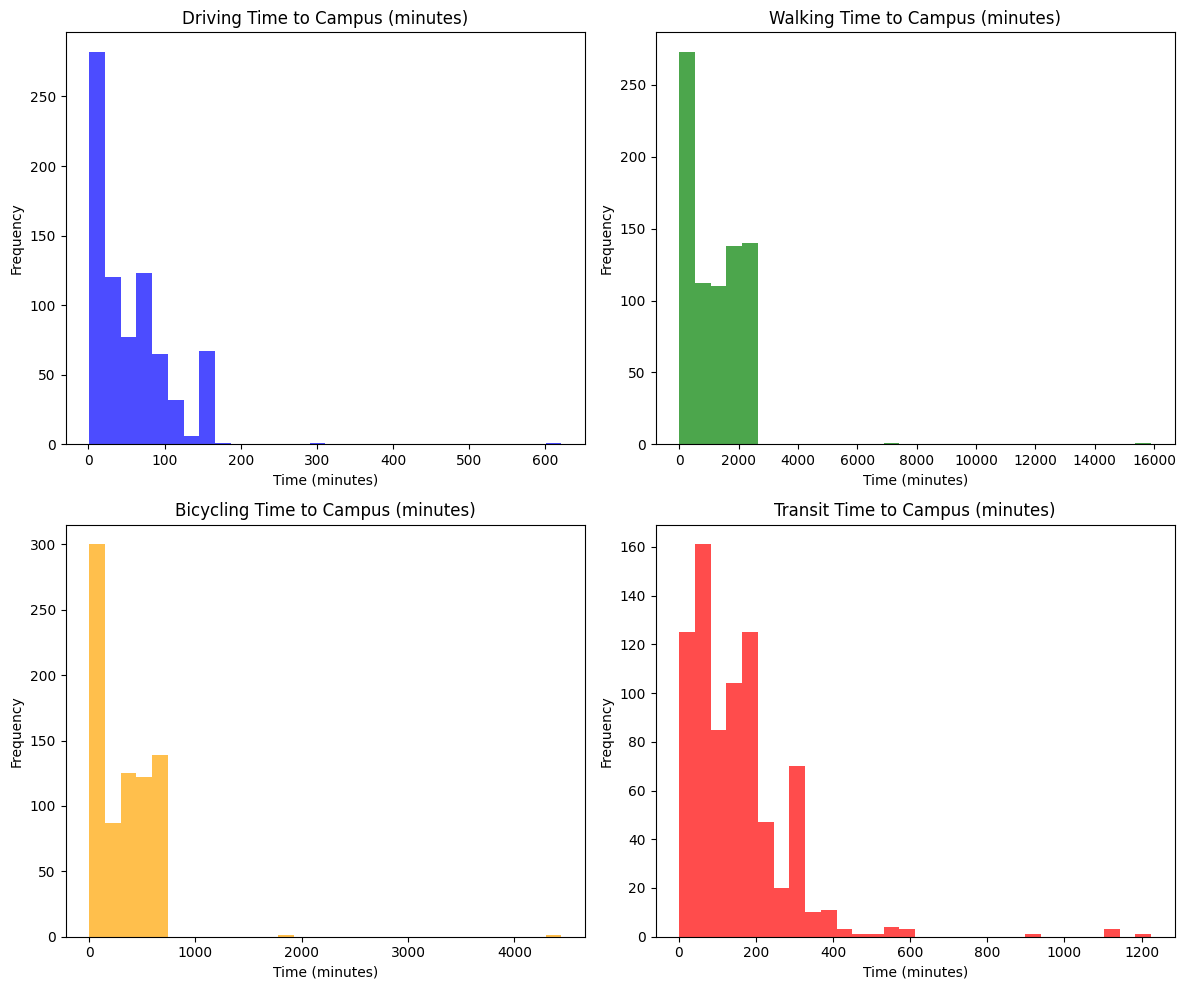

In [35]:
# plot histograms of transportation times on different axes to uncover any clustering patterns 
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].hist(grid_df['driving_time_to_campus'], bins=30, color='blue', alpha=0.7)
axs[0, 0].set_title('Driving Time to Campus (minutes)')
axs[0, 0].set_xlabel('Time (minutes)')
axs[0, 0].set_ylabel('Frequency')
axs[0, 1].hist(grid_df['walking_time_to_campus'], bins=30, color='green', alpha=0.7)
axs[0, 1].set_title('Walking Time to Campus (minutes)')
axs[0, 1].set_xlabel('Time (minutes)')
axs[0, 1].set_ylabel('Frequency')
axs[1, 0].hist(grid_df['bicycling_time_to_campus'], bins=30, color='orange', alpha=0.7)
axs[1, 0].set_title('Bicycling Time to Campus (minutes)')
axs[1, 0].set_xlabel('Time (minutes)')
axs[1, 0].set_ylabel('Frequency')
axs[1, 1].hist(grid_df['transit_time_to_campus'], bins=30, color='red', alpha=0.7)
axs[1, 1].set_title('Transit Time to Campus (minutes)')
axs[1, 1].set_xlabel('Time (minutes)')
axs[1, 1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Create new column for each transport method that labels them by K-means clusters of transportation time to campus, then visualize

In [36]:
# Using clustering algorithms such as KMeans to create new columns for each transport method that labels them by clusters of transportation time to campus
from sklearn.cluster import KMeans
kmeans_driving = KMeans(n_clusters=3, random_state=0).fit(grid_df[['driving_time_to_campus']])
grid_df['driving_time_cluster'] = kmeans_driving.labels_
kmeans_walking = KMeans(n_clusters=3, random_state=0).fit(grid_df[['walking_time_to_campus']])
grid_df['walking_time_cluster'] = kmeans_walking.labels_
kmeans_bicycling = KMeans(n_clusters=3, random_state=0).fit(grid_df[['bicycling_time_to_campus']])
grid_df['bicycling_time_cluster'] = kmeans_bicycling.labels_
kmeans_transit = KMeans(n_clusters=3, random_state=0).fit(grid_df[['transit_time_to_campus']])
grid_df['transit_time_cluster'] = kmeans_transit.labels_
grid_df.head()

,latitude,longitude,address,driving_time_to_campus,walking_time_to_campus,bicycling_time_to_campus,transit_time_to_campus,driving_time_cluster,walking_time_cluster,bicycling_time_cluster,transit_time_cluster
0,40.06,-123.80,"356X+2X Benbow, CA, USA",87,2220,678,206,2,0,0,0
1,40.06,-123.79,"3666+22 Benbow, CA, USA",91,2220,679,204,2,0,0,0
2,40.06,-123.78,"3669+2X Benbow, CA, USA",82,2220,675,190,2,0,0,0
3,40.06,-123.77,"366J+22 Benbow, CA, USA",87,2220,680,210,2,0,0,0
4,40.07,-123.81,"359R+X2 Garberville, CA, USA",87,2220,680,581,2,0,0,0


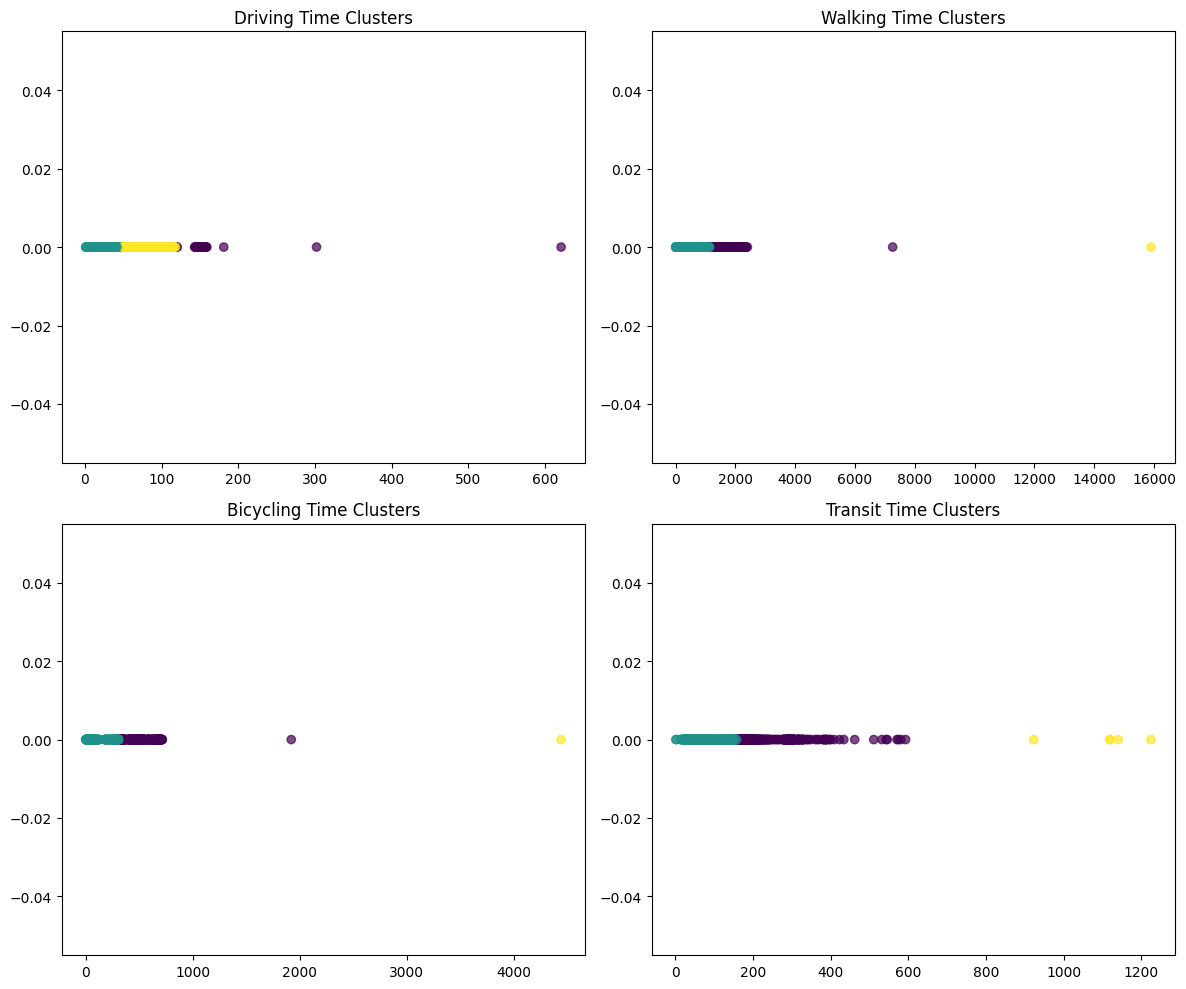

In [37]:
# Visualize each cluster for each transportation time
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
scatter1 = axs[0, 0].scatter(grid_df['driving_time_to_campus'], np.zeros_like(grid_df['driving_time_to_campus']), c=grid_df['driving_time_cluster'], cmap='viridis', alpha=0.7)
axs[0, 0].set_title('Driving Time Clusters')
scatter2 = axs[0, 1].scatter(grid_df['walking_time_to_campus'], np.zeros_like(grid_df['walking_time_to_campus']), c=grid_df['walking_time_cluster'], cmap='viridis', alpha=0.7)
axs[0, 1].set_title('Walking Time Clusters')
scatter3 = axs[1, 0].scatter(grid_df['bicycling_time_to_campus'], np.zeros_like(grid_df['bicycling_time_to_campus']), c=grid_df['bicycling_time_cluster'], cmap='viridis', alpha=0.7)
axs[1, 0].set_title('Bicycling Time Clusters')
scatter4 = axs[1, 1].scatter(grid_df['transit_time_to_campus'], np.zeros_like(grid_df['transit_time_to_campus']), c=grid_df['transit_time_cluster'], cmap='viridis', alpha=0.7)
axs[1, 1].set_title('Transit Time Clusters')
plt.tight_layout()
plt.show()

In [38]:
grid_df.to_csv('../clean_data/Kmeans_Clusters_Grid_Data.csv', index=False)

## Get Bus Stop Addresses to place as points on map visualizations in separate streamlit app

In [39]:
overpass_url = "https://overpass-api.de/api/interpreter"

bus_stops_df = pd.DataFrame(columns=['latitude', 'longitude', 'name'])
SOUTH, WEST, NORTH, EAST = 40.0, -124.5, 41.3, -123.0  # Define bounding box for the query

query = f"""
[out:json][timeout:25];
(
    node["highway"="bus_stop"]({SOUTH},{WEST},{NORTH},{EAST});
);
out body;
"""

response = requests.get(overpass_url, params={'data': query})

if response.status_code == 200:
        data = response.json()
        for element in data['elements']:
                lat = element['lat']
                lon = element['lon']
                name = element['tags'].get('name', 'Unknown')  # Get the name of the bus stop if available
                bus_stops_df = pd.concat([bus_stops_df, pd.DataFrame({
                        'latitude': [lat],
                        'longitude': [lon],
                        'name': [name]
                })], ignore_index=True)

bus_stops_df.head()
bus_stops_df.to_csv('../clean_data/Bus_Stops_Data.csv', index=False)

C:\Users\wolfe\AppData\Local\Temp\ipykernel_31464\1272897087.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bus_stops_df = pd.concat([bus_stops_df, pd.DataFrame({


# Done